In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os


In [14]:
X_train_pad = np.load(
    "/content/X_train.npy"
)

X_val_pad = np.load(
    "/content/X_val.npy"
)

X_test_pad = np.load(
    "/content/X_test.npy"
)

y_train = np.load(
    "/content/y_train.npy"
)

y_val = np.load(
    "/content/y_val.npy"
)

y_test = np.load(
    "/content/y_test.npy"
)

In [15]:
print("Training:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Testing:", X_test_pad.shape)

Training: (34998, 200)
Validation: (7502, 200)
Testing: (7500, 200)


In [16]:
VOCAB_SIZE = 20000

BASE_SEQUENCE_LENGTH = 200

BASE_EMBEDDING_DIM = 128

BASE_HIDDEN_UNITS = 64

BASE_DROPOUT = 0.3

BASE_BATCH_SIZE = 64

BASE_EPOCHS = 10

In [17]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("\n", model_name)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [18]:
#Build Baseline GRU
def build_baseline_GRU():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            64
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [19]:
#Train Baseline GRU
baseline_GRU = build_baseline_GRU()

baseline_history = baseline_GRU.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5270 - loss: 0.6886 - val_accuracy: 0.5966 - val_loss: 0.6432
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8393 - loss: 0.3737 - val_accuracy: 0.8816 - val_loss: 0.2823
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9311 - loss: 0.1944 - val_accuracy: 0.8815 - val_loss: 0.3020
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9631 - loss: 0.1126 - val_accuracy: 0.8748 - val_loss: 0.3748
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9812 - loss: 0.0612 - val_accuracy: 0.8628 - val_loss: 0.4972


In [20]:
#Evaluate Baseline GRU
baseline_result = evaluate_model(

    baseline_GRU,

    X_test_pad,

    y_test,

    "Baseline GRU"
)


 Baseline GRU
Accuracy: 0.8729
Precision: 0.8894
Recall: 0.8517
F1 Score: 0.8702
ROC-AUC: 0.9415


In [21]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

baseline_GRU.save(
    "saved_models/baseline_GRU.keras"
)

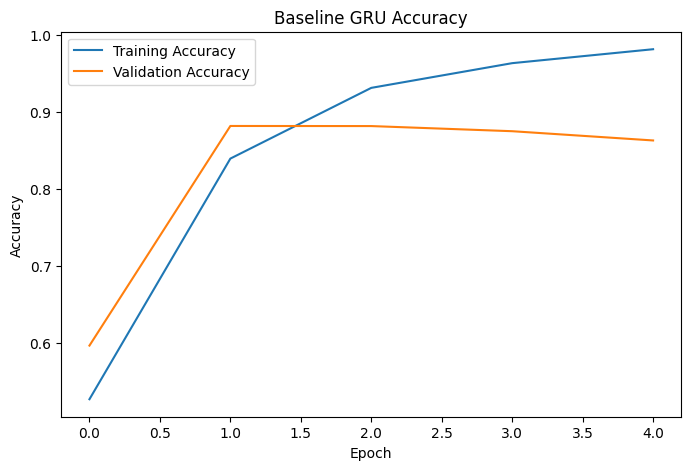

In [22]:
#Plot Baseline Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Baseline GRU Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [23]:
embedding_results = []

for embedding_dim in [64, 128, 256]:

    print(
        "\nTesting Embedding Dimension:",
        embedding_dim
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            input_length=200
        ),

        GRU(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    val_accuracy = max(
        history.history["val_accuracy"]
    )

    embedding_results.append({

        "Embedding Dimension": embedding_dim,

        "Validation Accuracy": val_accuracy

    })


Testing Embedding Dimension: 64
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5229 - loss: 0.6888 - val_accuracy: 0.5375 - val_loss: 0.6799
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7537 - loss: 0.4806 - val_accuracy: 0.8658 - val_loss: 0.3248
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9120 - loss: 0.2345 - val_accuracy: 0.8860 - val_loss: 0.2809

Testing Embedding Dimension: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5219 - loss: 0.6913 - val_accuracy: 0.5401 - val_loss: 0.6839
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7808 - loss: 0.4466 - val_accuracy: 0.8708 - val_loss: 0.3138
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9190 - loss: 0.2175 - val_accuracy: 0.8802 - val_loss: 0.2934

Testing Embedding Dimension: 256
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5591 - loss: 0.6684 - val_accuracy: 0.7898 - val_loss: 0.4695
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15

In [24]:
embedding_df = pd.DataFrame(
    embedding_results
)

embedding_df

,Embedding Dimension,Validation Accuracy
0,64,0.886030
1,128,0.880165
2,256,0.880165


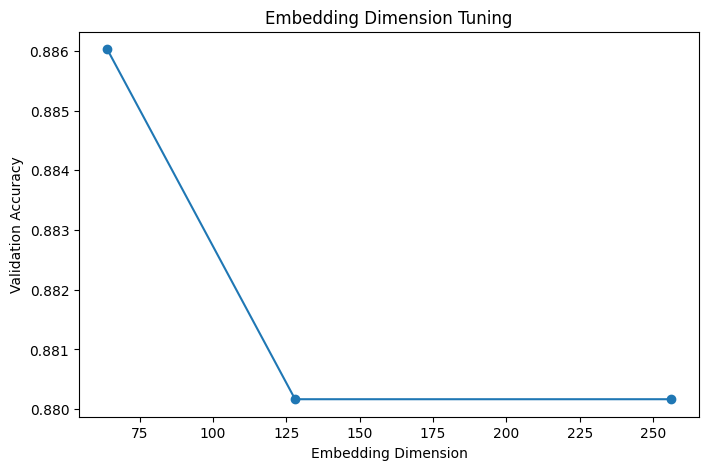

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_df["Embedding Dimension"],
    embedding_df["Validation Accuracy"],
    marker="o"
)

plt.title(
    "Embedding Dimension Tuning"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.show()

In [26]:
hidden_results = []

for units in [32, 64, 128]:

    print(
        "\nTesting Hidden Units:",
        units
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            units
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    hidden_results.append({

        "Hidden Units": units,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Hidden Units: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5502 - loss: 0.6780 - val_accuracy: 0.7662 - val_loss: 0.5364
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8489 - loss: 0.3793 - val_accuracy: 0.8724 - val_loss: 0.3112
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9247 - loss: 0.2208 - val_accuracy: 0.8752 - val_loss: 0.3079

Testing Hidden Units: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5302 - loss: 0.6884 - val_accuracy: 0.5429 - val_loss: 0.6835
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7994 - loss: 0.4301 - val_accuracy: 0.8715 - val_loss: 0.3000
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9213 - loss: 0.2164 - val_accuracy: 0.8838 - val_loss: 0.2861

Testing Hidden Units: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5365 - loss: 0.6857 - val_accuracy: 0.5341 - val_loss: 0.6840
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accu

In [27]:
hidden_df = pd.DataFrame(
    hidden_results
)

hidden_df

,Hidden Units,Validation Accuracy
0,32,0.875233
1,64,0.883764
2,128,0.883764


In [28]:
#Tune Dropout
dropout_results = []

for dropout_rate in [0.2, 0.3, 0.5]:

    print(
        "\nTesting Dropout:",
        dropout_rate
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    dropout_results.append({

        "Dropout": dropout_rate,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Dropout: 0.2
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5690 - loss: 0.6702 - val_accuracy: 0.5432 - val_loss: 0.6537
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8333 - loss: 0.3975 - val_accuracy: 0.8718 - val_loss: 0.3157
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9162 - loss: 0.2261 - val_accuracy: 0.8842 - val_loss: 0.2949

Testing Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5106 - loss: 0.6922 - val_accuracy: 0.5537 - val_loss: 0.6825
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7658 - loss: 0.4629 - val_accuracy: 0.8795 - val_loss: 0.2951
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9227 - loss: 0.2123 - val_accuracy: 0.8842 - val_loss: 0.2961

Testing Dropout: 0.5
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5238 - loss: 0.6883 - val_accuracy: 0.5092 - val_loss: 0.6873
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5

In [29]:
#Display Dropout Results
dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout,Validation Accuracy
0,0.2,0.884164
1,0.3,0.884164
2,0.5,0.872834


In [30]:
#Tune Recurrent Dropout
recurrent_results = []

for recurrent_dropout in [0.0, 0.2, 0.3]:

    print(
        "\nTesting Recurrent Dropout:",
        recurrent_dropout
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            64,
            dropout=0.3,
            recurrent_dropout=recurrent_dropout
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    recurrent_results.append({

        "Recurrent Dropout":
            recurrent_dropout,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Recurrent Dropout: 0.0
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5257 - loss: 0.6874 - val_accuracy: 0.5697 - val_loss: 0.6703
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8097 - loss: 0.4097 - val_accuracy: 0.8774 - val_loss: 0.2966
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9256 - loss: 0.2071 - val_accuracy: 0.8831 - val_loss: 0.2933

Testing Recurrent Dropout: 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 357s 646ms/step - accuracy: 0.5411 - loss: 0.6841 - val_accuracy: 0.5472 - val_loss: 0.6837
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 353s 645ms/step - accuracy: 0.7991 - loss: 0.4624 - val_accuracy: 0.8632 - val_loss: 0.3397
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 349s 637ms/step - accuracy: 0.8976 - loss: 0.2695 - val_accuracy: 0.8762 - val_loss: 0.2989

Testing Recurrent Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 385s 698ms/step - accuracy: 0.5293 - loss: 0.6872 - val_accuracy: 0.5525 - val_loss: 0.6798
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━

In [31]:
recurrent_df = pd.DataFrame(
    recurrent_results
)

recurrent_df

,Recurrent Dropout,Validation Accuracy
0,0.0,0.883098
1,0.2,0.876166
2,0.3,0.867235


In [32]:
#Try Batch Normalization
batchnorm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    GRU(
        64,
        dropout=0.3
    ),

    BatchNormalization(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
batchnorm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [34]:
batchnorm_history = batchnorm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5077 - loss: 0.7035 - val_accuracy: 0.5092 - val_loss: 0.6897
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7966 - loss: 0.4154 - val_accuracy: 0.8744 - val_loss: 0.2991
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9190 - loss: 0.2128 - val_accuracy: 0.8832 - val_loss: 0.3060
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9515 - loss: 0.1332 - val_accuracy: 0.8572 - val_loss: 0.4430
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9718 - loss: 0.0832 - val_accuracy: 0.8702 - val_loss: 0.4453


In [35]:
learning_rate_results = []

for lr in [0.001, 0.0005, 0.0001]:

    print(
        "\nTesting Learning Rate:",
        lr
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=lr
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    learning_rate_results.append({

        "Learning Rate": lr,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Learning Rate: 0.001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5370 - loss: 0.6840 - val_accuracy: 0.5525 - val_loss: 0.6703
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7722 - loss: 0.4588 - val_accuracy: 0.8822 - val_loss: 0.2914
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9203 - loss: 0.2228 - val_accuracy: 0.8855 - val_loss: 0.2792

Testing Learning Rate: 0.0005
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5189 - loss: 0.6878 - val_accuracy: 0.5716 - val_loss: 0.6561
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8204 - loss: 0.4144 - val_accuracy: 0.8740 - val_loss: 0.3088
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9127 - loss: 0.2354 - val_accuracy: 0.8815 - val_loss: 0.2843

Testing Learning Rate: 0.0001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5027 - loss: 0.6932 - val_accuracy: 0.5121 - val_loss: 0.6929
Epoch 2/3

In [36]:
learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Validation Accuracy
0,0.0010,0.885497
1,0.0005,0.881498
2,0.0001,0.550120


In [37]:
optimizer_results = []

optimizers = {

    "Adam": Adam(
        learning_rate=0.0005
    ),

    "RMSprop": RMSprop(
        learning_rate=0.0005
    )
}


for optimizer_name, optimizer in optimizers.items():

    print(
        "\nTesting Optimizer:",
        optimizer_name
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    optimizer_results.append({

        "Optimizer": optimizer_name,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Optimizer: Adam
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5307 - loss: 0.6876 - val_accuracy: 0.6020 - val_loss: 0.6542
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7316 - loss: 0.5045 - val_accuracy: 0.8488 - val_loss: 0.3447
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9042 - loss: 0.2566 - val_accuracy: 0.8839 - val_loss: 0.2809

Testing Optimizer: RMSprop
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5002 - loss: 0.6933 - val_accuracy: 0.5197 - val_loss: 0.6923
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5284 - loss: 0.6901 - val_accuracy: 0.5467 - val_loss: 0.6832
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6879 - loss: 0.6035 - val_accuracy: 0.7478 - val_loss: 0.5680


In [38]:
optimizer_df = pd.DataFrame(
    optimizer_results
)

optimizer_df

,Optimizer,Validation Accuracy
0,Adam,0.883898
1,RMSprop,0.747801


In [39]:
batch_results = []

for batch_size in [32, 64, 128]:

    print(
        "\nTesting Batch Size:",
        batch_size
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GRU(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=batch_size,

        verbose=1
    )

    batch_results.append({

        "Batch Size": batch_size,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Batch Size: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.5274 - loss: 0.6853 - val_accuracy: 0.5613 - val_loss: 0.6705
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8198 - loss: 0.4011 - val_accuracy: 0.8756 - val_loss: 0.2936
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9199 - loss: 0.2199 - val_accuracy: 0.8740 - val_loss: 0.3227

Testing Batch Size: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5121 - loss: 0.6919 - val_accuracy: 0.5324 - val_loss: 0.6872
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7162 - loss: 0.5420 - val_accuracy: 0.8456 - val_loss: 0.3543
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8929 - loss: 0.2782 - val_accuracy: 0.8642 - val_loss: 0.3102

Testing Batch Size: 128
Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5121 - loss: 0.6929 - val_accuracy: 0.5248 - val_loss: 0.6915
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - ac

In [40]:
batch_df = pd.DataFrame(
    batch_results
)

batch_df

,Batch Size,Validation Accuracy
0,32,0.875633
1,64,0.864170
2,128,0.524793


In [41]:
optimized_GRU = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    GRU(
        64,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [42]:
optimized_optimizer = Adam(
    learning_rate=0.0005
)


optimized_GRU.compile(

    optimizer=optimized_optimizer,

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


optimized_GRU.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_22 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

In [44]:
learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=0.00001
)

In [45]:
optimized_history = optimized_GRU.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)
optimized_history = optimized_GRU.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 362s 656ms/step - accuracy: 0.5152 - loss: 0.6913 - val_accuracy: 0.5488 - val_loss: 0.6798 - learning_rate: 5.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 355s 649ms/step - accuracy: 0.6202 - loss: 0.6325 - val_accuracy: 0.7731 - val_loss: 0.5310 - learning_rate: 5.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 351s 641ms/step - accuracy: 0.8305 - loss: 0.4100 - val_accuracy: 0.8476 - val_loss: 0.3659 - learning_rate: 5.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 354s 647ms/step - accuracy: 0.8901 - loss: 0.2919 - val_accuracy: 0.8711 - val_loss: 0.3116 - learning_rate: 5.0000e-04
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 348s 636ms/step - accuracy: 0.9249 - loss: 0.2103 - val_accuracy: 0.8764 - val_loss: 0.3164 - learning_rate: 5.0000e-04
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 349s 639ms/step - accuracy: 0.9508 - loss: 0.1503 - val_accuracy: 0.8743 - val_loss: 0.3479 - learning_rate: 2.5000e-04
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [46]:
optimized_GRU.save(
    "saved_models/optimized_GRU.keras"
)

print(
    "Optimized GRU saved successfully!"
)

Optimized GRU saved successfully!


In [47]:
optimized_result = evaluate_model(

    optimized_GRU,

    X_test_pad,

    y_test,

    "Optimized GRU"
)


 Optimized GRU
Accuracy: 0.876
Precision: 0.867
Recall: 0.8883
F1 Score: 0.8775
ROC-AUC: 0.9458


In [48]:
comparison = pd.DataFrame([

    baseline_result,

    optimized_result

])

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline GRU,0.8729,0.8894,0.8517,0.8702,0.9415
1,Optimized GRU,0.8760,0.8670,0.8883,0.8775,0.9458


In [49]:
accuracy_improvement = (

    optimized_result["Accuracy"]

    -

    baseline_result["Accuracy"]
)

f1_improvement = (

    optimized_result["F1 Score"]

    -

    baseline_result["F1 Score"]
)

roc_auc_improvement = (

    optimized_result["ROC-AUC"]

    -

    baseline_result["ROC-AUC"]
)


print(
    "Accuracy Improvement:",
    round(
        accuracy_improvement,
        4
    )
)

print(
    "F1 Score Improvement:",
    round(
        f1_improvement,
        4
    )
)

print(
    "ROC-AUC Improvement:",
    round(
        roc_auc_improvement,
        4
    )
)

Accuracy Improvement: 0.0031
F1 Score Improvement: 0.0073
ROC-AUC Improvement: 0.0042


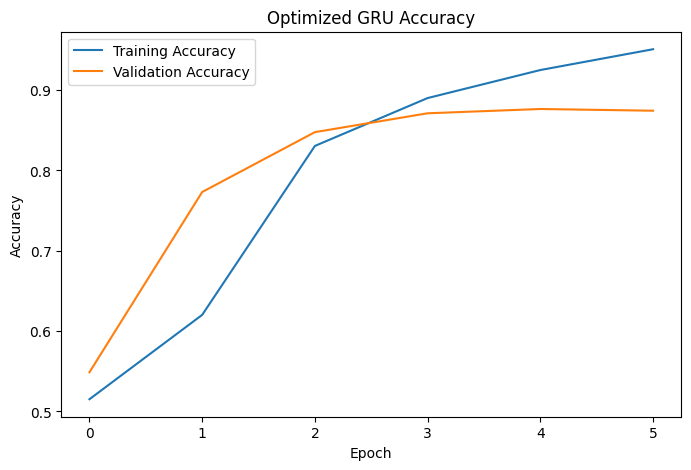

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "accuracy"
    ],

    label="Training Accuracy"
)

plt.plot(

    optimized_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)

plt.title(
    "Optimized GRU Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

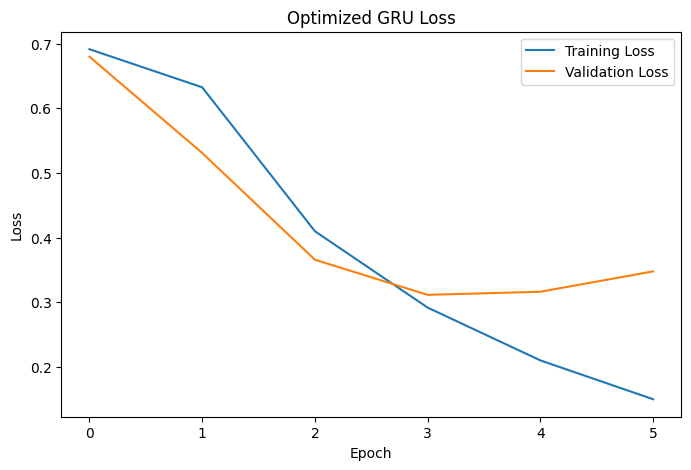

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "loss"
    ],

    label="Training Loss"
)

plt.plot(

    optimized_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)

plt.title(
    "Optimized GRU Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [52]:
embedding_df.to_csv(
    "saved_models/embedding_tuning.csv",
    index=False
)

hidden_df.to_csv(
    "saved_models/hidden_units_tuning.csv",
    index=False
)

dropout_df.to_csv(
    "saved_models/dropout_tuning.csv",
    index=False
)

recurrent_df.to_csv(
    "saved_models/recurrent_dropout_tuning.csv",
    index=False
)

learning_rate_df.to_csv(
    "saved_models/learning_rate_tuning.csv",
    index=False
)

optimizer_df.to_csv(
    "saved_models/optimizer_tuning.csv",
    index=False
)

batch_df.to_csv(
    "saved_models/batch_size_tuning.csv",
    index=False
)

comparison.to_csv(
    "saved_models/baseline_vs_optimized.csv",
    index=False
)

In [53]:
print("=" * 60)

print("PHASE 5 - MODEL IMPROVEMENT COMPLETED")

print("=" * 60)

print("\nBaseline GRU Accuracy:")

print(
    round(
        baseline_result["Accuracy"],
        4
    )
)

print("\nOptimized GRU Accuracy:")

print(
    round(
        optimized_result["Accuracy"],
        4
    )
)

print("\nAccuracy Improvement:")

print(
    round(
        accuracy_improvement,
        4
    )
)

print("\nBaseline F1 Score:")

print(
    round(
        baseline_result["F1 Score"],
        4
    )
)

print("\nOptimized F1 Score:")

print(
    round(
        optimized_result["F1 Score"],
        4
    )
)

print("\nF1 Improvement:")

print(
    round(
        f1_improvement,
        4
    )
)

print("\nOptimized Model Saved At:")

print(
    "saved_models/optimized_GRU.keras"
)

PHASE 5 - MODEL IMPROVEMENT COMPLETED

Baseline GRU Accuracy:
0.8729

Optimized GRU Accuracy:
0.876

Accuracy Improvement:
0.0031

Baseline F1 Score:
0.8702

Optimized F1 Score:
0.8775

F1 Improvement:
0.0073

Optimized Model Saved At:
saved_models/optimized_GRU.keras
